<a href="https://colab.research.google.com/github/vu1f2425010-cpu/yuva-/blob/main/task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

H1 T-Test: t=-32.29, p=0.00000


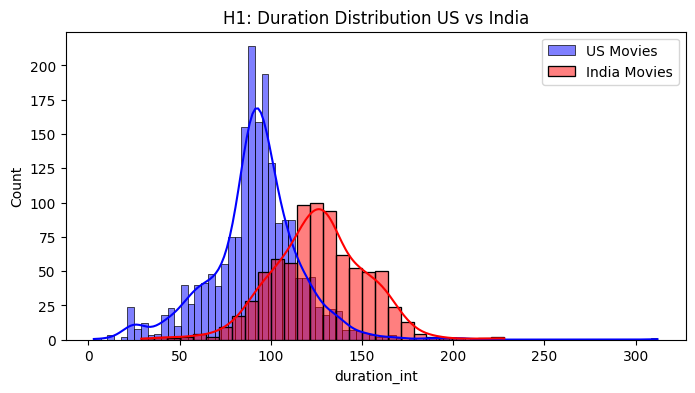

H2 Chi-Square: chi2=829.72, p=0.00000, dof=13


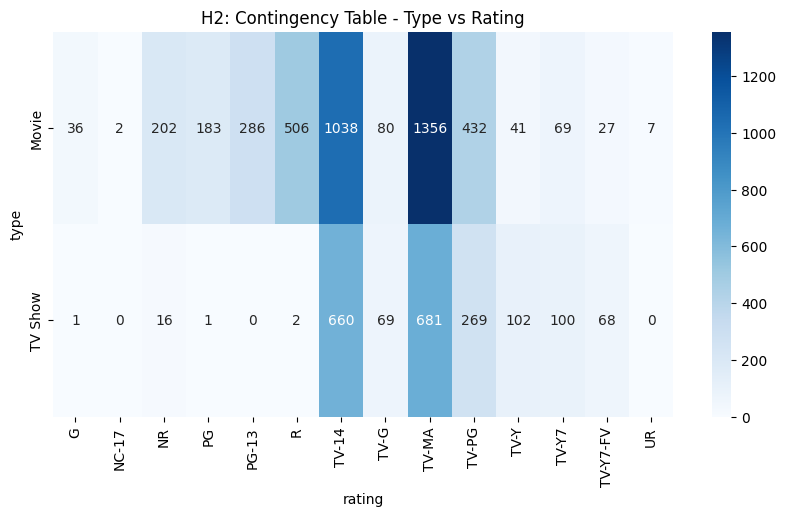

H3 ANOVA: F=52.47, p=0.00000


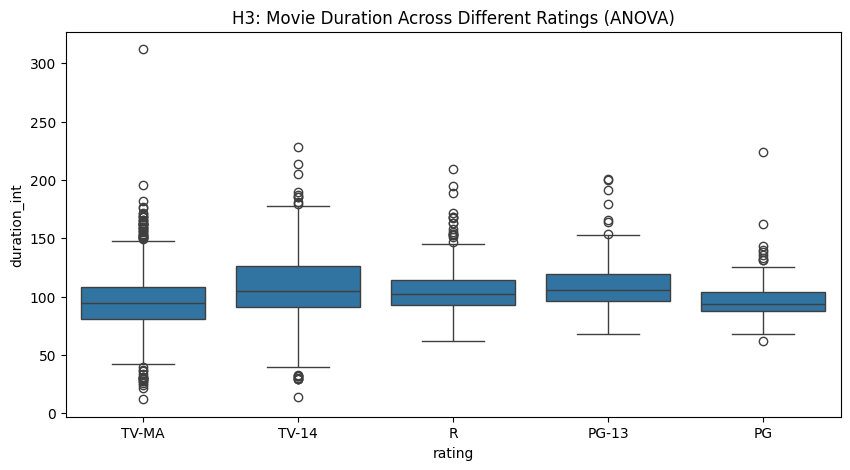

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load
url = 'https://raw.githubusercontent.com/Sharath432/EDA-NETFLIX-/main/netflix_titles.csv'
df = pd.read_csv(url)

# Cleaning
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].fillna('Unknown')
df_clean = df[df['date_added']!='Unknown'].copy()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), format='mixed')

# For duration
df_movie = df[df['type']=='Movie'].copy()
df_movie['duration_int'] = df_movie['duration'].str.replace(' min','').astype(int)

# ---------------- HYPOTHESIS 1: T-Test ----------------
# H0: US and India movies have same average duration
# H1: US and India movies have different average duration
us_dur = df_movie[df_movie['country'].str.contains('United States', na=False)]['duration_int']
india_dur = df_movie[df_movie['country'].str.contains('India', na=False)]['duration_int']

t_stat, p_val_t = stats.ttest_ind(us_dur, india_dur, equal_var=False)
print(f"H1 T-Test: t={t_stat:.2f}, p={p_val_t:.5f}")

plt.figure(figsize=(8,4))
sns.histplot(us_dur, color='blue', label='US Movies', kde=True, alpha=0.5)
sns.histplot(india_dur, color='red', label='India Movies', kde=True, alpha=0.5)
plt.title('H1: Duration Distribution US vs India')
plt.legend()
plt.show()

# ---------------- HYPOTHESIS 2: Chi-Square Test ----------------
# H0: Content Type and Rating are independent
# H1: Content Type and Rating are dependent
contingency = pd.crosstab(df['type'], df['rating'])
chi2, p_val_chi, dof, exp = stats.chi2_contingency(contingency)
print(f"H2 Chi-Square: chi2={chi2:.2f}, p={p_val_chi:.5f}, dof={dof}")

plt.figure(figsize=(10,5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.title('H2: Contingency Table - Type vs Rating')
plt.show()

# ---------------- HYPOTHESIS 3: ANOVA Test ----------------
# H0: Average movie duration is same across all ratings
# H1: Atleast one rating has different average duration
top_ratings = ['PG-13', 'R', 'PG', 'TV-MA', 'TV-14']
groups = [df_movie[df_movie['rating']==r]['duration_int'] for r in top_ratings]
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"H3 ANOVA: F={f_stat:.2f}, p={p_val_anova:.5f}")

plt.figure(figsize=(10,5))
sns.boxplot(data=df_movie[df_movie['rating'].isin(top_ratings)], x='rating', y='duration_int')
plt.title('H3: Movie Duration Across Different Ratings (ANOVA)')
plt.show()